# 2. Krzywe Wypełniające Przestrzeń

## Wprowadzenie

**Krzywe wypełniające przestrzeń** (space-filling curves) to ciągłe krzywe, które przechodzą przez każdy punkt pewnego obszaru (np. kwadratu jednostkowego). Pierwszy przykład takiej krzywej został skonstruowany przez **Giuseppe Peano** w 1890 roku.

### Paradoks

Intuicyjnie wydaje się niemożliwe, aby jednowymiarowa krzywa mogła "wypełnić" dwuwymiarowy obszar. Jednak matematycznie jest to możliwe - krzywa ta ma:
- **Wymiar topologiczny**: 1 (jest to krzywa)
- **Wymiar fraktalny (Minkowskiego)**: 2 (wypełnia przestrzeń)

### Krzywe analizowane w tym notebooku:
1. **Krzywa Hilberta** - najpopularniejsza, łatwa w konstrukcji
2. **Krzywa Peano** - oryginalna konstrukcja z 1890 roku
3. **Krzywa smoka** (Dragon curve) - fraktal powstający przez składanie papieru

In [1]:
# Importy
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
import sys
sys.path.insert(0, '..')

from src.space_filling import hilbert_curve, peano_curve, dragon_curve
from src.box_counting import curve_to_points, box_counting_dimension

# Konfiguracja wykresów
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100

print("Moduły załadowane pomyślnie!")

Moduły załadowane pomyślnie!


## 2.1 Krzywa Hilberta

Krzywa Hilberta jest definiowana rekurencyjnie. Dla rzędu $n$:
- Liczba punktów: $4^n$
- Długość segmentu: $2^{-n}$
- Całkowita długość: $L_n = 4^n \cdot 2^{-n} = 2^n \to \infty$

### Konstrukcja
Każdy kolejny rząd powstaje przez:
1. Stworzenie 4 kopii poprzedniego rzędu
2. Odpowiednie obrócenie i odbicie kopii
3. Połączenie ich w kształt litery U

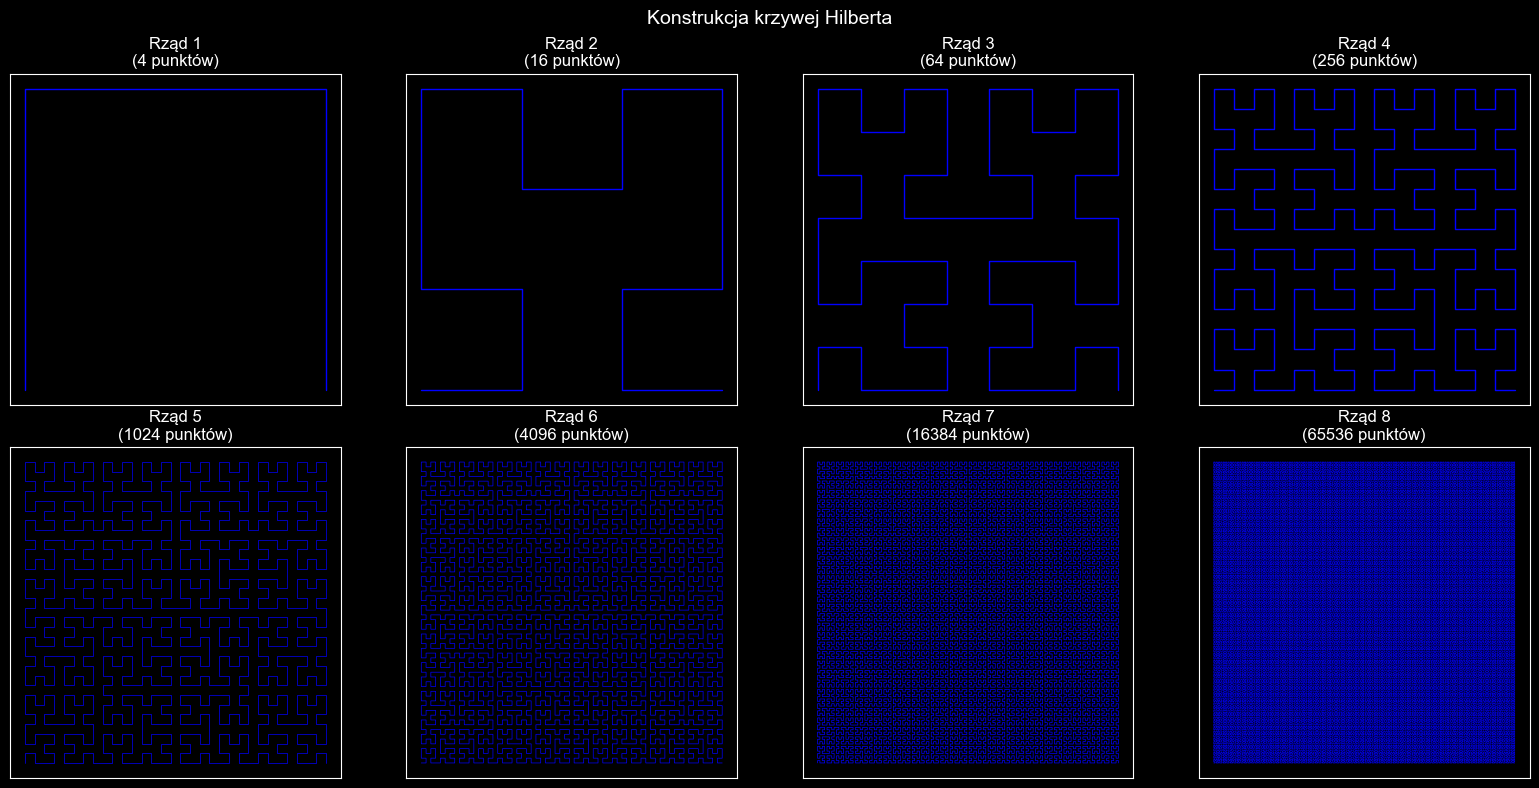

In [2]:
# Budowa krzywej Hilberta krok po kroku
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
orders = range(1, 9)

for ax, order in zip(axes.flat, orders):
    x, y = hilbert_curve(order)
    ax.plot(x, y, 'b-', linewidth=0.5 if order > 4 else 1)
    ax.set_title(f'Rząd {order}\n({len(x)} punktów)')
    ax.set_aspect('equal')
    ax.set_xticks([])
    ax.set_yticks([])

plt.suptitle('Konstrukcja krzywej Hilberta', fontsize=14)
plt.tight_layout()
plt.savefig('../output/figures/hilbert_construction.png', dpi=150)
plt.show()

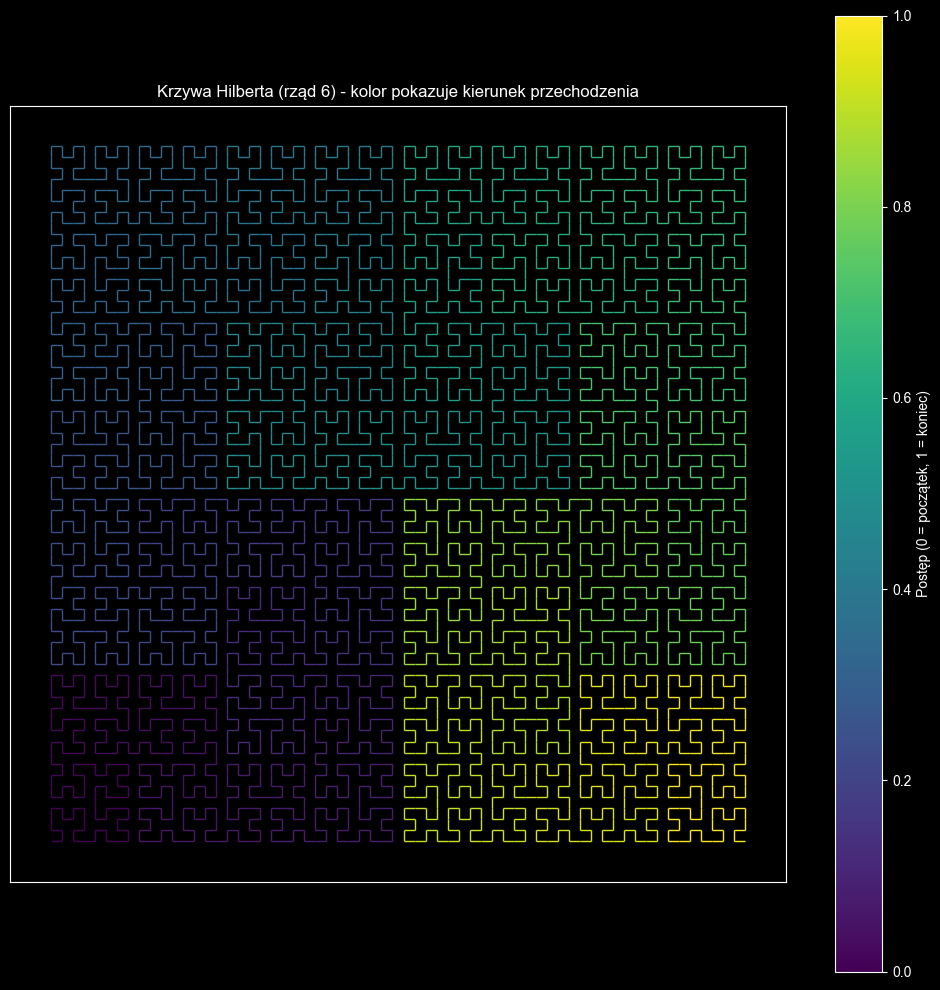

In [3]:
# Krzywa Hilberta z kolorową gradacją pokazującą kierunek
order = 6
x, y = hilbert_curve(order)

fig, ax = plt.subplots(figsize=(10, 10))

# Tworzymy segmenty z gradientem kolorów
points = np.array([x, y]).T.reshape(-1, 1, 2)
segments = np.concatenate([points[:-1], points[1:]], axis=1)

# Kolorowanie według kolejności
colors = plt.cm.viridis(np.linspace(0, 1, len(segments)))
lc = LineCollection(segments, colors=colors, linewidth=1)
ax.add_collection(lc)

ax.set_xlim(-0.05, 1.05)
ax.set_ylim(-0.05, 1.05)
ax.set_aspect('equal')
ax.set_title(f'Krzywa Hilberta (rząd {order}) - kolor pokazuje kierunek przechodzenia')
ax.set_xticks([])
ax.set_yticks([])

# Colorbar
sm = plt.cm.ScalarMappable(cmap='viridis', norm=plt.Normalize(0, 1))
cbar = plt.colorbar(sm, ax=ax, label='Postęp (0 = początek, 1 = koniec)')

plt.tight_layout()
plt.savefig('../output/figures/hilbert_colored.png', dpi=150)
plt.show()

## 2.2 Krzywa Peano

Oryginalna krzywa Peano z 1890 roku. Dla rzędu $n$:
- Liczba punktów: $9^n$
- Bazuje na podziale kwadratu na 9 części

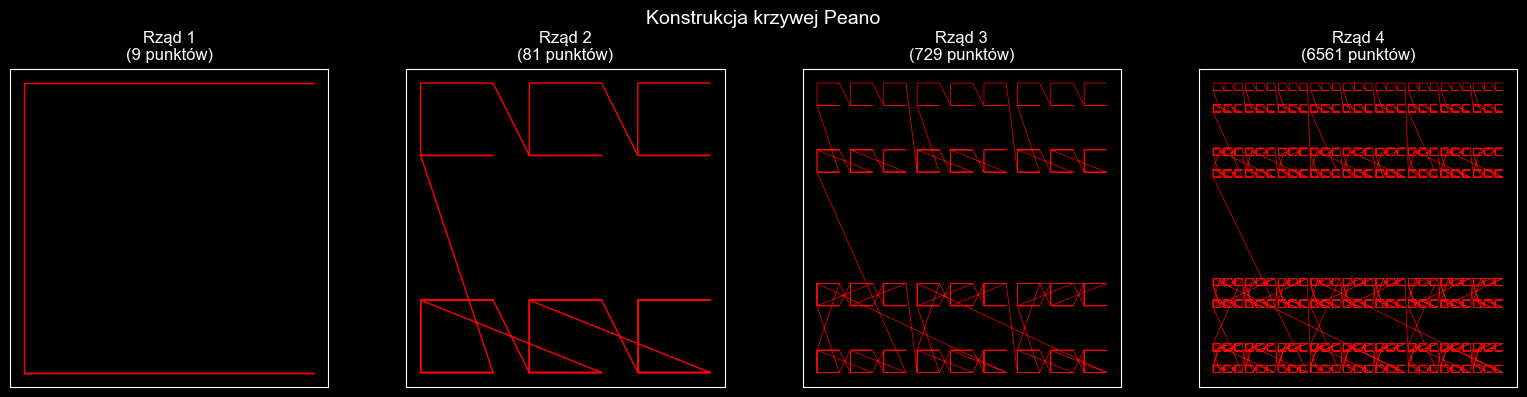

In [4]:
# Budowa krzywej Peano
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
orders = [1, 2, 3, 4]

for ax, order in zip(axes, orders):
    x, y = peano_curve(order)
    ax.plot(x, y, 'r-', linewidth=0.5 if order > 2 else 1)
    ax.set_title(f'Rząd {order}\n({len(x)} punktów)')
    ax.set_aspect('equal')
    ax.set_xticks([])
    ax.set_yticks([])

plt.suptitle('Konstrukcja krzywej Peano', fontsize=14)
plt.tight_layout()
plt.savefig('../output/figures/peano_construction.png', dpi=150)
plt.show()

## 2.3 Krzywa Smoka (Dragon Curve)

Krzywa smoka to fraktal powstający przez wielokrotne składanie paska papieru zawsze w tym samym kierunku, a następnie rozłożenie go tak, aby każde zgięcie tworzyło kąt prosty.

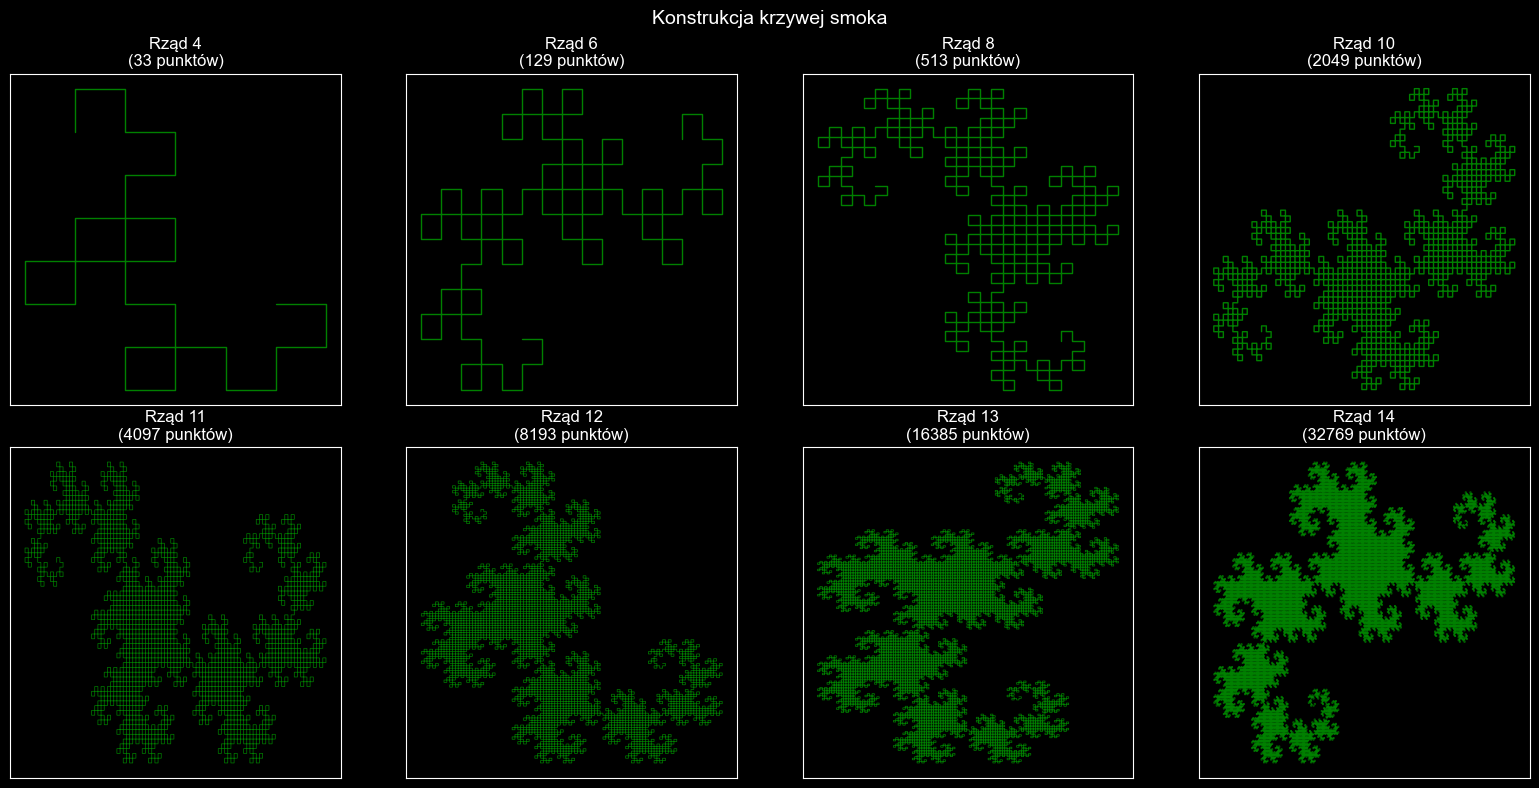

In [5]:
# Budowa krzywej smoka
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
orders = [4, 6, 8, 10, 11, 12, 13, 14]

for ax, order in zip(axes.flat, orders):
    x, y = dragon_curve(order)
    ax.plot(x, y, 'g-', linewidth=0.5 if order > 10 else 1)
    ax.set_title(f'Rząd {order}\n({len(x)} punktów)')
    ax.set_aspect('equal')
    ax.set_xticks([])
    ax.set_yticks([])

plt.suptitle('Konstrukcja krzywej smoka', fontsize=14)
plt.tight_layout()
plt.savefig('../output/figures/dragon_construction.png', dpi=150)
plt.show()

## 2.4 Porównanie krzywych

Porównajmy wszystkie trzy krzywe obok siebie.

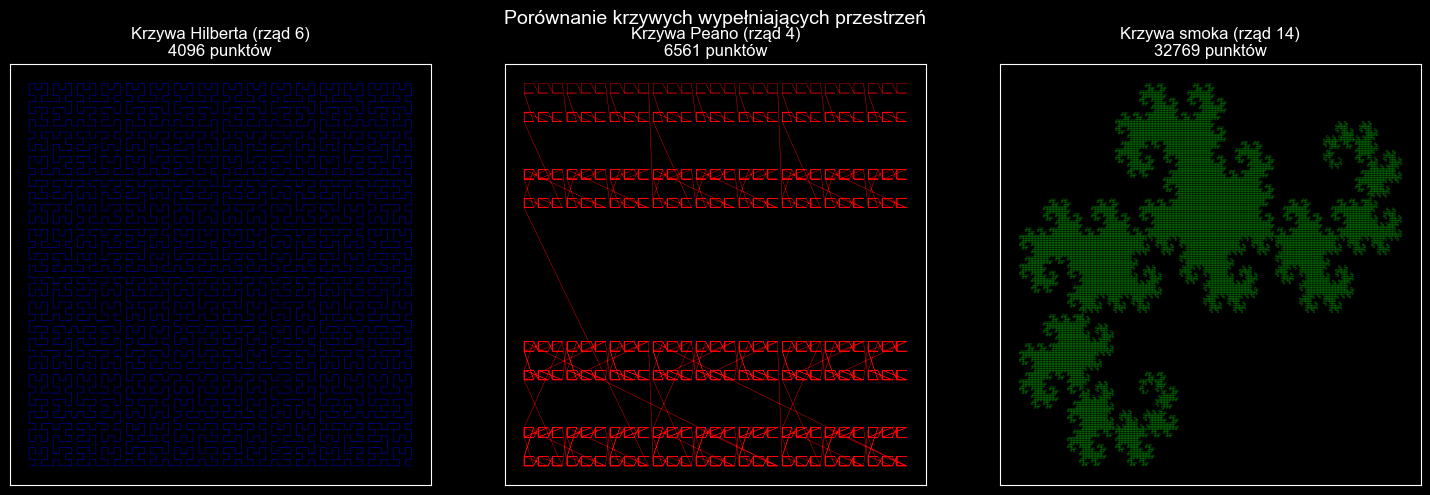

In [6]:
# Porównanie trzech krzywych
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Hilbert
x, y = hilbert_curve(6)
axes[0].plot(x, y, 'b-', linewidth=0.3)
axes[0].set_title(f'Krzywa Hilberta (rząd 6)\n{len(x)} punktów')
axes[0].set_aspect('equal')
axes[0].set_xticks([])
axes[0].set_yticks([])

# Peano
x, y = peano_curve(4)
axes[1].plot(x, y, 'r-', linewidth=0.3)
axes[1].set_title(f'Krzywa Peano (rząd 4)\n{len(x)} punktów')
axes[1].set_aspect('equal')
axes[1].set_xticks([])
axes[1].set_yticks([])

# Dragon
x, y = dragon_curve(14)
axes[2].plot(x, y, 'g-', linewidth=0.3)
axes[2].set_title(f'Krzywa smoka (rząd 14)\n{len(x)} punktów')
axes[2].set_aspect('equal')
axes[2].set_xticks([])
axes[2].set_yticks([])

plt.suptitle('Porównanie krzywych wypełniających przestrzeń', fontsize=14)
plt.tight_layout()
plt.savefig('../output/figures/curves_comparison.png', dpi=150)
plt.show()

## 2.5 Analiza wymiaru fraktalnego

Zbadajmy wymiar Minkowskiego krzywych metodą box-counting.

### Oczekiwane wartości:
- **Krzywa Hilberta** (granica): D = 2 (wypełnia kwadrat)
- **Krzywa Peano** (granica): D = 2 (wypełnia kwadrat)
- **Krzywa smoka**: D = 2 (granica krzywej smoka jest wypełniającą przestrzeń)

In [7]:
# Obliczenie wymiaru dla krzywej Hilberta przy różnych rzędach
print("Analiza wymiaru krzywej Hilberta:")
print("-" * 50)

hilbert_results = []
for order in [4, 5, 6, 7]:
    x, y = hilbert_curve(order)
    points = curve_to_points(x, y)
    
    dim, r2, _ = box_counting_dimension(points, epsilon_min=0.005, epsilon_max=0.2, n_epsilons=20)
    hilbert_results.append({'order': order, 'points': len(x), 'dimension': dim, 'r2': r2})
    
    print(f"Rząd {order}: {len(x):>6} punktów, D = {dim:.4f}, R² = {r2:.4f}")

print("\nOczekiwany wymiar dla granicy: D = 2.0")

Analiza wymiaru krzywej Hilberta:
--------------------------------------------------
Rząd 4:    256 punktów, D = 0.4597, R² = 0.5767
Rząd 5:   1024 punktów, D = 0.9706, R² = 0.7986
Rząd 6:   4096 punktów, D = 1.4847, R² = 0.9328
Rząd 7:  16384 punktów, D = 1.8577, R² = 0.9922

Oczekiwany wymiar dla granicy: D = 2.0


In [8]:
# Obliczenie wymiaru dla krzywej Peano
print("\nAnaliza wymiaru krzywej Peano:")
print("-" * 50)

peano_results = []
for order in [2, 3, 4]:
    x, y = peano_curve(order)
    points = curve_to_points(x, y)
    
    dim, r2, _ = box_counting_dimension(points, epsilon_min=0.005, epsilon_max=0.2, n_epsilons=20)
    peano_results.append({'order': order, 'points': len(x), 'dimension': dim, 'r2': r2})
    
    print(f"Rząd {order}: {len(x):>6} punktów, D = {dim:.4f}, R² = {r2:.4f}")


Analiza wymiaru krzywej Peano:
--------------------------------------------------
Rząd 2:     81 punktów, D = 0.0666, R² = 0.2955
Rząd 3:    729 punktów, D = 0.5656, R² = 0.7046
Rząd 4:   6561 punktów, D = 1.1778, R² = 0.9212


In [9]:
# Obliczenie wymiaru dla krzywej smoka
print("\nAnaliza wymiaru krzywej smoka:")
print("-" * 50)

dragon_results = []
for order in [10, 12, 14, 16]:
    x, y = dragon_curve(order)
    points = curve_to_points(x, y)
    
    dim, r2, _ = box_counting_dimension(points, epsilon_min=0.005, epsilon_max=0.2, n_epsilons=20)
    dragon_results.append({'order': order, 'points': len(x), 'dimension': dim, 'r2': r2})
    
    print(f"Rząd {order}: {len(x):>6} punktów, D = {dim:.4f}, R² = {r2:.4f}")


Analiza wymiaru krzywej smoka:
--------------------------------------------------
Rząd 10:   2049 punktów, D = 1.2166, R² = 0.9179
Rząd 12:   8193 punktów, D = 1.6007, R² = 0.9885
Rząd 14:  32769 punktów, D = 1.7554, R² = 0.9995
Rząd 16: 131073 punktów, D = 1.7690, R² = 0.9994


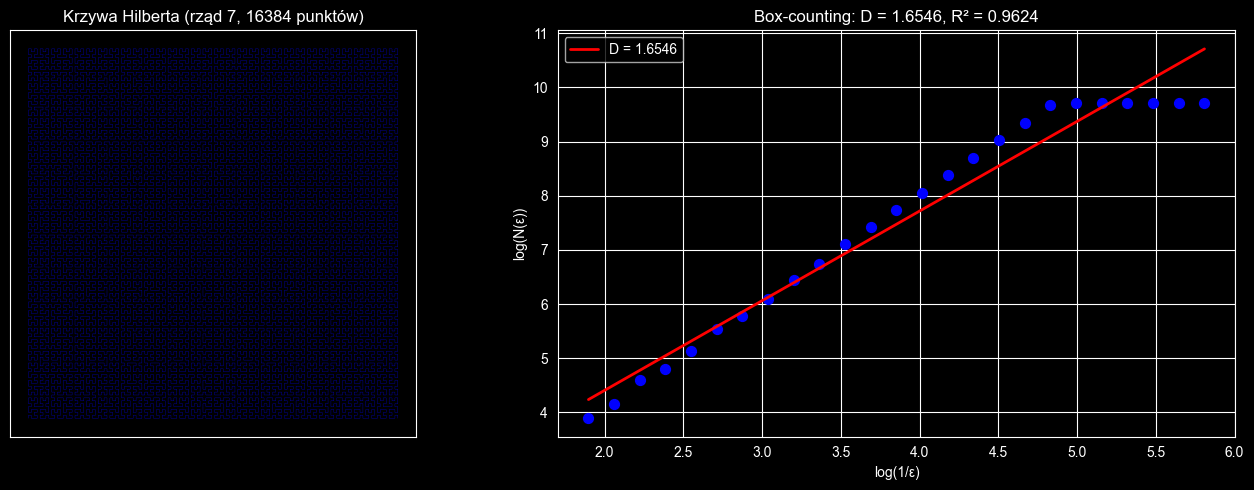

In [10]:
# Wizualizacja analizy box-counting dla krzywej Hilberta
x, y = hilbert_curve(7)
points = curve_to_points(x, y)
dim, r2, details = box_counting_dimension(points, epsilon_min=0.003, epsilon_max=0.15, n_epsilons=25)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Lewa - krzywa
axes[0].plot(x, y, 'b-', linewidth=0.2)
axes[0].set_aspect('equal')
axes[0].set_title(f'Krzywa Hilberta (rząd 7, {len(x)} punktów)')
axes[0].set_xticks([])
axes[0].set_yticks([])

# Prawa - box-counting
axes[1].scatter(details['log_inv_eps'], details['log_counts'], s=50, c='blue')
axes[1].plot(details['log_inv_eps'],
             details['slope'] * details['log_inv_eps'] + details['intercept'],
             'r-', linewidth=2, label=f'D = {dim:.4f}')
axes[1].set_xlabel('log(1/ε)')
axes[1].set_ylabel('log(N(ε))')
axes[1].set_title(f'Box-counting: D = {dim:.4f}, R² = {r2:.4f}')
axes[1].legend()

plt.tight_layout()
plt.savefig('../output/figures/hilbert_box_counting.png', dpi=150)
plt.show()

## 2.6 Własności krzywych wypełniających przestrzeń

### Analiza długości krzywej

In [11]:
# Analiza długości krzywej Hilberta
print("Długość krzywej Hilberta:")
print("-" * 50)
print(f"{'Rząd':<10} {'Punktów':<12} {'Długość':<15} {'Teoretyczna':<15}")
print("-" * 50)

for order in range(1, 9):
    x, y = hilbert_curve(order)
    
    # Obliczamy długość jako sumę odległości między kolejnymi punktami
    dx = np.diff(x)
    dy = np.diff(y)
    length = np.sum(np.sqrt(dx**2 + dy**2))
    
    # Teoretyczna długość: (4^n - 1) * (1/2^n) ≈ 2^n - 2^(-n)
    theoretical = (4**order - 1) / (2**order)
    
    print(f"{order:<10} {len(x):<12} {length:<15.6f} {theoretical:<15.6f}")

print("\nWniosek: Długość rośnie wykładniczo (∝ 2^n) → w granicy nieskończona!")

Długość krzywej Hilberta:
--------------------------------------------------
Rząd       Punktów      Długość         Teoretyczna    
--------------------------------------------------
1          4            1.500000        1.500000       
2          16           3.750000        3.750000       
3          64           7.875000        7.875000       
4          256          15.937500       15.937500      
5          1024         31.968750       31.968750      
6          4096         63.984375       63.984375      
7          16384        127.992188      127.992188     
8          65536        255.996094      255.996094     

Wniosek: Długość rośnie wykładniczo (∝ 2^n) → w granicy nieskończona!


## 2.7 Podsumowanie

### Kluczowe wnioski:

1. **Krzywe wypełniające przestrzeń** są ciągłymi krzywymi, które przechodzą przez każdy punkt kwadratu jednostkowego.

2. **Wymiar fraktalny** dla granicy tych krzywych wynosi 2, co potwierdza że wypełniają one przestrzeń.

3. Dla skończonych iteracji wymiar jest bliski 1 (krzywa jest jednowymiarowa), ale rośnie z liczbą iteracji.

4. **Długość krzywej** rośnie wykładniczo z rzędem - w granicy jest nieskończona.

5. **Zastosowania**:
   - Kompresja danych przestrzennych
   - Indeksowanie baz danych geograficznych
   - Dithering w grafice komputerowej
   - Mapowanie pamięci cache

In [12]:
# Zapisanie wyników
import pandas as pd

all_results = []
for r in hilbert_results:
    r['curve'] = 'Hilbert'
    all_results.append(r)
for r in peano_results:
    r['curve'] = 'Peano'
    all_results.append(r)
for r in dragon_results:
    r['curve'] = 'Dragon'
    all_results.append(r)

df = pd.DataFrame(all_results)
df.to_csv('../output/data/space_filling_dimensions.csv', index=False)
print("Wyniki zapisane do: output/data/space_filling_dimensions.csv")
print("\nTabela wyników:")
print(df.to_string(index=False))

Wyniki zapisane do: output/data/space_filling_dimensions.csv

Tabela wyników:
 order  points  dimension       r2   curve
     4     256   0.459712 0.576650 Hilbert
     5    1024   0.970618 0.798636 Hilbert
     6    4096   1.484671 0.932763 Hilbert
     7   16384   1.857716 0.992178 Hilbert
     2      81   0.066637 0.295450   Peano
     3     729   0.565597 0.704563   Peano
     4    6561   1.177758 0.921223   Peano
    10    2049   1.216603 0.917942  Dragon
    12    8193   1.600740 0.988506  Dragon
    14   32769   1.755356 0.999489  Dragon
    16  131073   1.768987 0.999449  Dragon
